# Section 10: Improving Robustness

In [1]:
# ============================================================
# Section 10: Improving Robustness with Cross-validation
# Fresh Start: Load Titanic and LendingClub from OpenML
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    KFold,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    TimeSeriesSplit
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    BaggingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [2]:
# 1. Load Titanic Dataset from OpenML

print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML

print('Fetching LendingClub dataset from OpenML...')
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


## Titanic Dataset

A single train-test split can give unstable results.

Cross-validation gives a more robust estimate by training and validating the model multiple times on different folds.

In this section, we use:

1. Train-test split baseline  
2. K-Fold Cross-validation  
3. Stratified K-Fold Cross-validation  
4. Repeated Stratified K-Fold  
5. Regularization comparison  
6. Ensembling comparison  

In [3]:
# ============================================================
# 10A. Prepare Titanic Dataset
# ============================================================

titanic_model = titanic_df.copy()

target_col = "survived"

# Convert target to integer
titanic_model[target_col] = titanic_model[target_col].astype(int)

# Treat pclass as categorical
if "pclass" in titanic_model.columns:
    titanic_model["pclass"] = titanic_model["pclass"].astype("category")

# Separate X and y first
X_titanic = titanic_model.drop(columns=[target_col]).copy()
y_titanic = titanic_model[target_col].copy()

# Drop columns that may cause leakage or high-cardinality noise
cols_to_drop = ["name", "ticket", "cabin", "boat", "body", "home.dest"]
X_titanic = X_titanic.drop(columns=cols_to_drop, errors="ignore")

# Identify categorical and numeric columns
cat_cols = X_titanic.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_titanic.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_titanic[col] = X_titanic[col].astype("object")
    X_titanic[col] = X_titanic[col].fillna("missing")
    X_titanic[col] = X_titanic[col].astype(str).str.strip().str.lower()

# One-hot encode categorical columns
# Numeric imputation is deferred to each Pipeline to avoid leaking test-fold statistics
X_titanic = pd.get_dummies(
    X_titanic,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

print("Titanic X shape:", X_titanic.shape)
print("Titanic y shape:", y_titanic.shape)

display(y_titanic.value_counts())
display(y_titanic.value_counts(normalize=True))

Titanic X shape: (1309, 10)
Titanic y shape: (1309,)


survived
0    809
1    500
Name: count, dtype: int64

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

In [4]:
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.2,
    random_state=42,
    stratify=y_titanic
)

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train_titanic, y_train_titanic)

baseline_preds = baseline_model.predict(X_test_titanic)
baseline_proba = baseline_model.predict_proba(X_test_titanic)[:, 1]

baseline_results = {
    "accuracy": accuracy_score(y_test_titanic, baseline_preds),
    "precision": precision_score(y_test_titanic, baseline_preds),
    "recall": recall_score(y_test_titanic, baseline_preds),
    "f1": f1_score(y_test_titanic, baseline_preds),
    "roc_auc": roc_auc_score(y_test_titanic, baseline_proba)
}

display(pd.DataFrame([baseline_results]))

,accuracy,precision,recall,f1,roc_auc
0,0.805344,0.763441,0.71,0.735751,0.867253


### K-Fold Cross-validation

K-Fold splits data into K folds.

For each round:

- Train on K-1 folds
- Validate on the remaining fold
- Repeat until each fold has been used as validation once

In [5]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kfold_scores = cross_val_score(
    logistic_model,
    X_titanic,
    y_titanic,
    cv=kfold,
    scoring="f1"
)

print("K-Fold F1 scores:", kfold_scores)
print("Mean F1:", kfold_scores.mean())
print("Std F1:", kfold_scores.std())

K-Fold F1 scores: [0.72037915 0.72131148 0.70769231 0.72189349 0.68867925]
Mean F1: 0.7119911332857709
Std F1: 0.012784430097000496


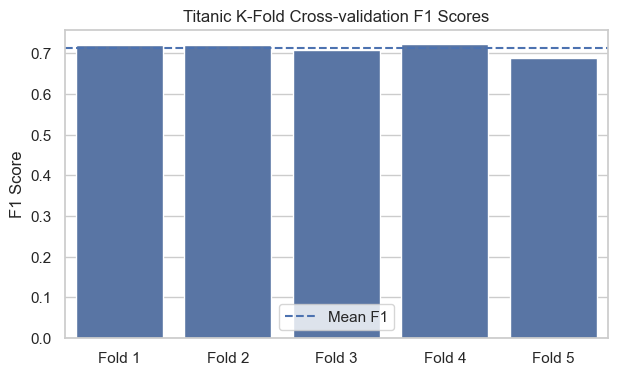

In [6]:
plt.figure(figsize=(7, 4))
sns.barplot(x=[f"Fold {i+1}" for i in range(len(kfold_scores))], y=kfold_scores)
plt.axhline(kfold_scores.mean(), linestyle="--", label="Mean F1")
plt.title("Titanic K-Fold Cross-validation F1 Scores")
plt.ylabel("F1 Score")
plt.legend()
plt.show()

### Stratified K-Fold Cross-validation

For classification, Stratified K-Fold is usually better than plain K-Fold.

It preserves the class ratio in each fold.

In [7]:
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = cross_val_score(
    logistic_model,
    X_titanic,
    y_titanic,
    cv=stratified_kfold,
    scoring="f1"
)

print("Stratified K-Fold F1 scores:", stratified_scores)
print("Mean F1:", stratified_scores.mean())
print("Std F1:", stratified_scores.std())

Stratified K-Fold F1 scores: [0.69791667 0.73       0.67741935 0.73096447 0.7253886 ]
Mean F1: 0.7123378179093443
Std F1: 0.021243805399901873


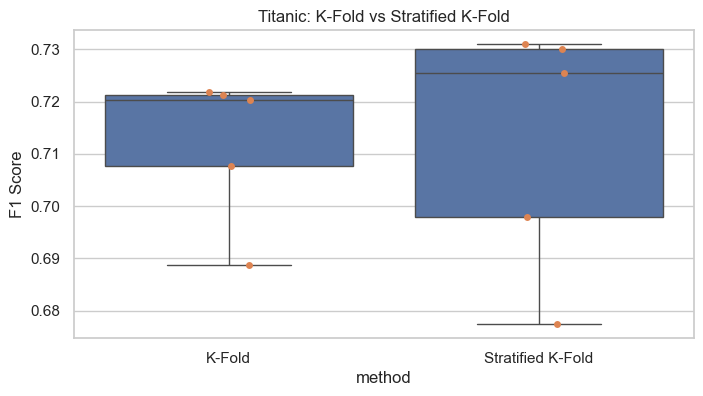

In [8]:
cv_comparison = pd.DataFrame({
    "method": ["K-Fold"] * len(kfold_scores) + ["Stratified K-Fold"] * len(stratified_scores),
    "f1": list(kfold_scores) + list(stratified_scores)
})

plt.figure(figsize=(8, 4))
sns.boxplot(data=cv_comparison, x="method", y="f1")
sns.stripplot(data=cv_comparison, x="method", y="f1")
plt.title("Titanic: K-Fold vs Stratified K-Fold")
plt.ylabel("F1 Score")
plt.show()

### Cross-validation with Multiple Metrics

Instead of scoring with one metric, we can evaluate several metrics together.

In [9]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    logistic_model,
    X_titanic,
    y_titanic,
    cv=stratified_kfold,
    scoring=scoring,
    return_train_score=True
)

cv_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "train_mean": [
        cv_results["train_accuracy"].mean(),
        cv_results["train_precision"].mean(),
        cv_results["train_recall"].mean(),
        cv_results["train_f1"].mean(),
        cv_results["train_roc_auc"].mean()
    ],
    "test_mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "test_std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

display(cv_summary)

,metric,train_mean,test_mean,test_std
0,accuracy,0.789534,0.787631,0.010819
1,precision,0.739836,0.737155,0.009153
2,recall,0.692500,0.690000,0.036332
3,f1,0.715337,0.712338,0.021244
4,roc_auc,0.844520,0.839849,0.026394


### Repeated Stratified K-Fold

Repeated CV runs Stratified K-Fold multiple times with different splits.

This gives an even more stable estimate.

In [10]:
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

repeated_scores = cross_val_score(
    logistic_model,
    X_titanic,
    y_titanic,
    cv=repeated_cv,
    scoring="f1"
)

print("Number of CV scores:", len(repeated_scores))
print("Mean F1:", repeated_scores.mean())
print("Std F1:", repeated_scores.std())

Number of CV scores: 15
Mean F1: 0.7104386800355431
Std F1: 0.026724953471292813


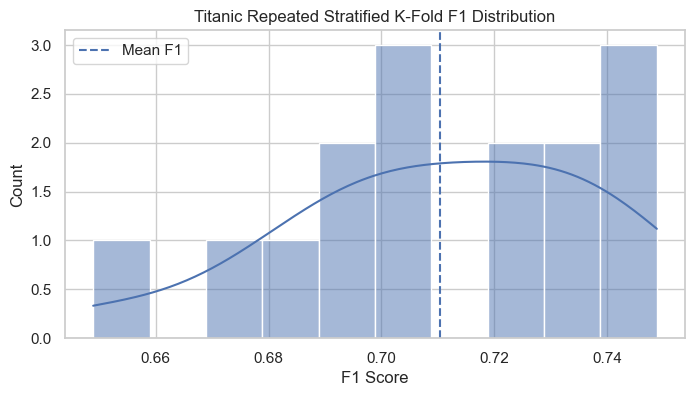

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(repeated_scores, bins=10, kde=True)
plt.axvline(repeated_scores.mean(), linestyle="--", label="Mean F1")
plt.title("Titanic Repeated Stratified K-Fold F1 Distribution")
plt.xlabel("F1 Score")
plt.legend()
plt.show()

### Regularization for Robustness

Regularization reduces overfitting.

For Logistic Regression:

- Smaller C means stronger regularization.
- Larger C means weaker regularization.

In [12]:
regularization_results = []

for C_value in [0.01, 0.1, 1, 10, 100]:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C_value,
            max_iter=1000,
            solver="liblinear"
        ))
    ])

    scores = cross_val_score(
        model,
        X_titanic,
        y_titanic,
        cv=stratified_kfold,
        scoring="f1"
    )

    regularization_results.append({
        "C": C_value,
        "mean_f1": scores.mean(),
        "std_f1": scores.std()
    })

regularization_results_df = pd.DataFrame(regularization_results)

display(regularization_results_df)

,C,mean_f1,std_f1
0,0.01,0.710184,0.034591
1,0.10,0.712742,0.025022
2,1.00,0.712338,0.021244
3,10.00,0.712344,0.019489
4,100.00,0.712344,0.019489


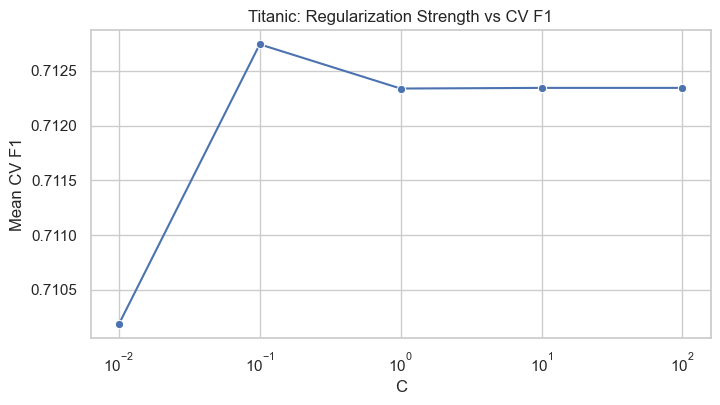

In [13]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=regularization_results_df, x="C", y="mean_f1", marker="o")
plt.xscale("log")
plt.title("Titanic: Regularization Strength vs CV F1")
plt.xlabel("C")
plt.ylabel("Mean CV F1")
plt.show()

### Ensembling for Robustness

Ensembling combines multiple models to reduce variance or improve performance.

Examples:

- Bagging
- Random Forest
- Boosting
- Stacking

In [14]:
ensemble_models = {
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(random_state=42, max_depth=4))
    ]),

    "Bagging": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=100,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ])
}

ensemble_results = []

for model_name, model in ensemble_models.items():
    scores = cross_val_score(
        model,
        X_titanic,
        y_titanic,
        cv=stratified_kfold,
        scoring="f1"
    )

    ensemble_results.append({
        "model": model_name,
        "mean_f1": scores.mean(),
        "std_f1": scores.std()
    })

ensemble_results_df = pd.DataFrame(ensemble_results).sort_values("mean_f1", ascending=False)

display(ensemble_results_df)

,model,mean_f1,std_f1
0,Decision Tree,0.743440,0.039380
3,Gradient Boosting,0.729033,0.034729
2,Random Forest,0.720603,0.029586
1,Bagging,0.715671,0.033560


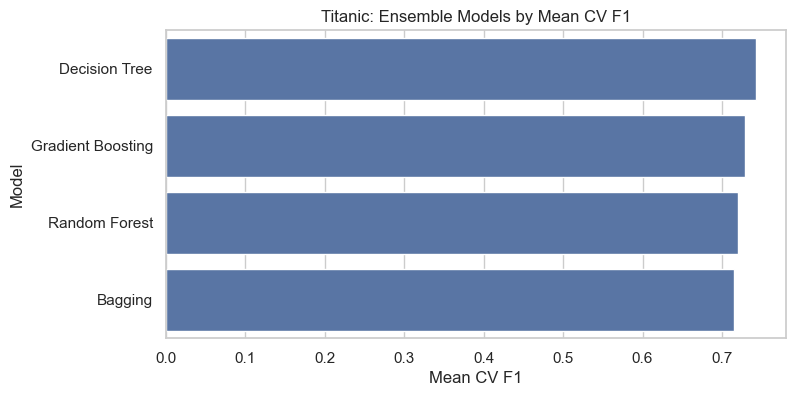

In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(data=ensemble_results_df, x="mean_f1", y="model")
plt.title("Titanic: Ensemble Models by Mean CV F1")
plt.xlabel("Mean CV F1")
plt.ylabel("Model")
plt.show()

# LendingClub Dataset


LendingClub is an imbalanced binary classification problem.

Target:

- `not_fully_paid = 0`: fully paid
- `not_fully_paid = 1`: not fully paid

For imbalanced classification, use Stratified K-Fold and metrics such as F1, recall, and ROC-AUC.

In [16]:
# ============================================================
# 10B. Prepare LendingClub Dataset
# ============================================================

lc_model = lending_df.copy()

# Normalize column names: OpenML may use dots (e.g. "not.fully.paid") — replace with underscores
lc_model.columns = lc_model.columns.str.replace('.', '_', regex=False)

target_col = "not_fully_paid"

# Convert target to integer
lc_model[target_col] = lc_model[target_col].astype(int)

# Separate X and y first
X_lc = lc_model.drop(columns=[target_col]).copy()
y_lc = lc_model[target_col].copy()

# Identify categorical and numeric columns
cat_cols = X_lc.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_lc.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_lc[col] = X_lc[col].astype("object")
    X_lc[col] = X_lc[col].fillna("missing")
    X_lc[col] = X_lc[col].astype(str).str.strip().str.lower()

# One-hot encode categorical columns
# Numeric imputation is deferred to each Pipeline to avoid leaking test-fold statistics
X_lc = pd.get_dummies(
    X_lc,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Replace infinite values with NaN so Pipeline imputers can handle them
X_lc = X_lc.replace([np.inf, -np.inf], np.nan)

print("LendingClub X shape:", X_lc.shape)
print("LendingClub y shape:", y_lc.shape)

display(y_lc.value_counts())
display(y_lc.value_counts(normalize=True))

LendingClub X shape: (9578, 18)
LendingClub y shape: (9578,)


not_fully_paid
0    8045
1    1533
Name: count, dtype: int64

not_fully_paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64

## Train-Test Split Baseline

Start with a single stratified train-test split.

In [17]:
X_train_lc, X_test_lc, y_train_lc, y_test_lc = train_test_split(
    X_lc,
    y_lc,
    test_size=0.2,
    random_state=42,
    stratify=y_lc
)

lc_baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

lc_baseline_model.fit(X_train_lc, y_train_lc)

lc_baseline_preds = lc_baseline_model.predict(X_test_lc)
lc_baseline_proba = lc_baseline_model.predict_proba(X_test_lc)[:, 1]

lc_baseline_results = {
    "accuracy": accuracy_score(y_test_lc, lc_baseline_preds),
    "precision": precision_score(y_test_lc, lc_baseline_preds, zero_division=0),
    "recall": recall_score(y_test_lc, lc_baseline_preds, zero_division=0),
    "f1": f1_score(y_test_lc, lc_baseline_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test_lc, lc_baseline_proba)
}

display(pd.DataFrame([lc_baseline_results]))

,accuracy,precision,recall,f1,roc_auc
0,0.640397,0.239071,0.570033,0.336862,0.684468


### Stratified K-Fold Cross-validation

For LendingClub, Stratified K-Fold is preferred because the default/risk class is imbalanced.

In [18]:
lc_stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lc_logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

lc_f1_scores = cross_val_score(
    lc_logistic_model,
    X_lc,
    y_lc,
    cv=lc_stratified_kfold,
    scoring="f1"
)

print("LendingClub Stratified K-Fold F1 scores:", lc_f1_scores)
print("Mean F1:", lc_f1_scores.mean())
print("Std F1:", lc_f1_scores.std())

LendingClub Stratified K-Fold F1 scores: [0.35477941 0.34354689 0.34593573 0.35238095 0.35201573]
Mean F1: 0.34973174279770725
Std F1: 0.004251494390404958


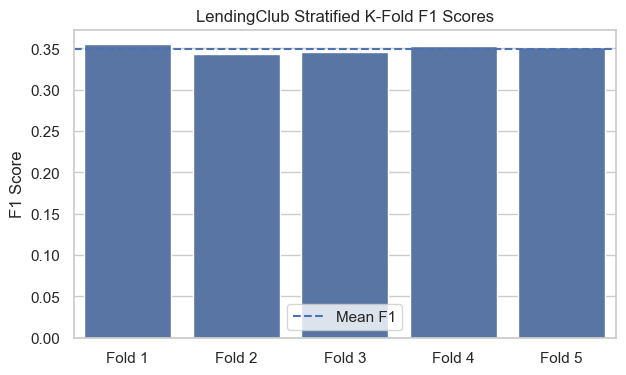

In [19]:
plt.figure(figsize=(7, 4))
sns.barplot(x=[f"Fold {i+1}" for i in range(len(lc_f1_scores))], y=lc_f1_scores)
plt.axhline(lc_f1_scores.mean(), linestyle="--", label="Mean F1")
plt.title("LendingClub Stratified K-Fold F1 Scores")
plt.ylabel("F1 Score")
plt.legend()
plt.show()

### Cross-validation with Multiple Metrics

For LendingClub, compare accuracy with more useful metrics such as recall, F1, and ROC-AUC.

In [20]:
lc_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

lc_cv_results = cross_validate(
    lc_logistic_model,
    X_lc,
    y_lc,
    cv=lc_stratified_kfold,
    scoring=lc_scoring,
    return_train_score=True
)

lc_cv_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "train_mean": [
        lc_cv_results["train_accuracy"].mean(),
        lc_cv_results["train_precision"].mean(),
        lc_cv_results["train_recall"].mean(),
        lc_cv_results["train_f1"].mean(),
        lc_cv_results["train_roc_auc"].mean()
    ],
    "test_mean": [
        lc_cv_results["test_accuracy"].mean(),
        lc_cv_results["test_precision"].mean(),
        lc_cv_results["test_recall"].mean(),
        lc_cv_results["test_f1"].mean(),
        lc_cv_results["test_roc_auc"].mean()
    ],
    "test_std": [
        lc_cv_results["test_accuracy"].std(),
        lc_cv_results["test_precision"].std(),
        lc_cv_results["test_recall"].std(),
        lc_cv_results["test_f1"].std(),
        lc_cv_results["test_roc_auc"].std()
    ]
})

display(lc_cv_summary)

,metric,train_mean,test_mean,test_std
0,accuracy,0.641183,0.640846,0.008896
1,precision,0.246832,0.246294,0.003985
2,recall,0.605349,0.603381,0.014377
3,f1,0.350672,0.349732,0.004251
4,roc_auc,0.685537,0.680136,0.002551


### Repeated Stratified K-Fold

Repeated Stratified K-Fold gives a more stable estimate of performance by repeating the CV process.

In [21]:
lc_repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

lc_repeated_scores = cross_val_score(
    lc_logistic_model,
    X_lc,
    y_lc,
    cv=lc_repeated_cv,
    scoring="f1"
)

print("Number of scores:", len(lc_repeated_scores))
print("Mean F1:", lc_repeated_scores.mean())
print("Std F1:", lc_repeated_scores.std())

Number of scores: 15
Mean F1: 0.34595702671686623
Std F1: 0.011933149807888559


### Regularization for Robustness

Regularization reduces overfitting.

Here we tune Logistic Regression regularization strength using cross-validation.

In [22]:
lc_regularization_results = []

for C_value in [0.001, 0.01, 0.1, 1, 10, 100]:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C_value,
            max_iter=1000,
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    scores = cross_val_score(
        model,
        X_lc,
        y_lc,
        cv=lc_stratified_kfold,
        scoring="f1"
    )

    lc_regularization_results.append({
        "C": C_value,
        "mean_f1": scores.mean(),
        "std_f1": scores.std()
    })

lc_regularization_results_df = pd.DataFrame(lc_regularization_results)

display(lc_regularization_results_df)

,C,mean_f1,std_f1
0,0.001,0.346148,0.006988
1,0.010,0.350069,0.006967
2,0.100,0.349193,0.005401
3,1.000,0.349722,0.005143
4,10.000,0.349355,0.004682
5,100.000,0.349355,0.004682


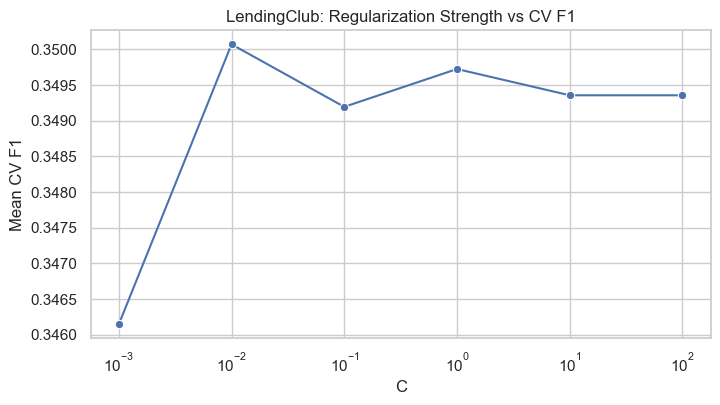

In [23]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=lc_regularization_results_df, x="C", y="mean_f1", marker="o")
plt.xscale("log")
plt.title("LendingClub: Regularization Strength vs CV F1")
plt.xlabel("C")
plt.ylabel("Mean CV F1")
plt.show()

### Ensembling for Robustness

Ensemble methods often improve robustness by combining multiple weak or unstable models.

In [24]:
lc_ensemble_models = {
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            random_state=42,
            max_depth=5,
            class_weight="balanced"
        ))
    ]),

    "Bagging": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ])
}

lc_ensemble_results = []

for model_name, model in lc_ensemble_models.items():
    scores = cross_val_score(
        model,
        X_lc,
        y_lc,
        cv=lc_stratified_kfold,
        scoring="f1"
    )

    lc_ensemble_results.append({
        "model": model_name,
        "mean_f1": scores.mean(),
        "std_f1": scores.std()
    })

lc_ensemble_results_df = pd.DataFrame(lc_ensemble_results).sort_values("mean_f1", ascending=False)

display(lc_ensemble_results_df)

,model,mean_f1,std_f1
0,Decision Tree,0.327182,0.008163
3,Gradient Boosting,0.052407,0.009377
1,Bagging,0.038392,0.012456
2,Random Forest,0.014062,0.010197


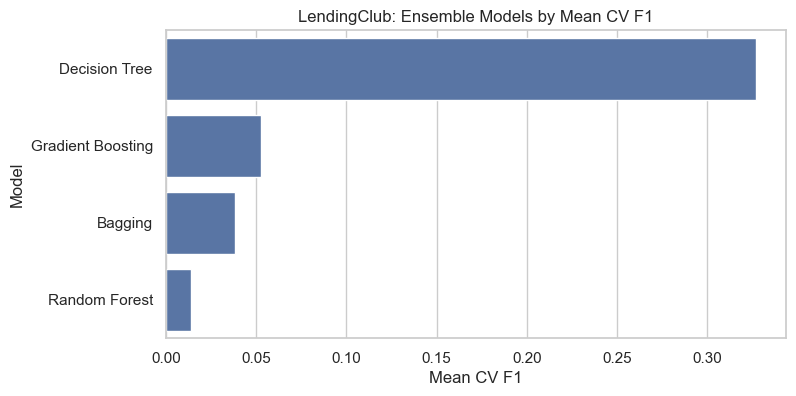

In [25]:
plt.figure(figsize=(8, 4))
sns.barplot(data=lc_ensemble_results_df, x="mean_f1", y="model")
plt.title("LendingClub: Ensemble Models by Mean CV F1")
plt.xlabel("Mean CV F1")
plt.ylabel("Model")
plt.show()

# Time Series Cross-validation Example

TimeSeriesSplit is useful when data has natural time order.

In time series problems, we should not randomly shuffle because that can leak future information into training.

Titanic and this LendingClub version are not true time-series examples, so this is a demonstration using row order.

In [26]:
# Demonstration only: TimeSeriesSplit on LendingClub row order

time_series_split = TimeSeriesSplit(n_splits=5)

ts_scores = []

for fold, (train_index, test_index) in enumerate(time_series_split.split(X_lc), start=1):
    X_train_ts, X_test_ts = X_lc.iloc[train_index], X_lc.iloc[test_index]
    y_train_ts, y_test_ts = y_lc.iloc[train_index], y_lc.iloc[test_index]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ])

    model.fit(X_train_ts, y_train_ts)
    preds = model.predict(X_test_ts)

    fold_f1 = f1_score(y_test_ts, preds, zero_division=0)

    ts_scores.append({
        "fold": fold,
        "train_size": len(train_index),
        "test_size": len(test_index),
        "f1": fold_f1
    })

ts_scores_df = pd.DataFrame(ts_scores)

display(ts_scores_df)

,fold,train_size,test_size,f1
0,1,1598,1596,0.252553
1,2,3194,1596,0.266010
2,3,4790,1596,0.283857
3,4,6386,1596,0.367661
4,5,7982,1596,0.432074


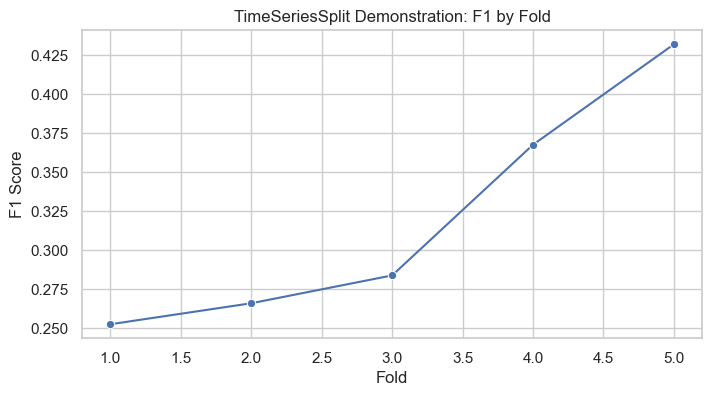

In [27]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=ts_scores_df, x="fold", y="f1", marker="o")
plt.title("TimeSeriesSplit Demonstration: F1 by Fold")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.show()

# Stacking Ensemble

Stacking combines predictions from multiple base models and trains a final model on top.

This can improve robustness, but it is more complex and less interpretable.

In [28]:
# Stacking example on Titanic because it is smaller and faster

base_estimators = [
    ("logistic", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ])),

    ("tree", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            max_depth=4,
            random_state=42
        ))
    ])),

    ("forest", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]))
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stacking_scores = cross_val_score(
    stacking_model,
    X_titanic,
    y_titanic,
    cv=stratified_kfold,
    scoring="f1"
)

print("Stacking F1 scores:", stacking_scores)
print("Mean F1:", stacking_scores.mean())
print("Std F1:", stacking_scores.std())

Stacking F1 scores: [0.62576687 0.67515924 0.66242038 0.73988439 0.63694268]
Mean F1: 0.6680347114445717
Std F1: 0.03999485299295676


In [29]:
robustness_methods = pd.DataFrame({
    "method": [
        "K-Fold CV",
        "Stratified K-Fold CV",
        "Repeated Stratified K-Fold",
        "TimeSeriesSplit",
        "Regularization",
        "Bagging",
        "Random Forest",
        "Boosting",
        "Stacking",
        "Early Stopping"
    ],
    "main_use": [
        "Estimate model performance more reliably",
        "Preserve class balance in each fold",
        "Reduce dependency on one random split",
        "Evaluate ordered/time-based data safely",
        "Reduce overfitting",
        "Reduce model variance",
        "Robust tree ensemble",
        "Reduce bias and improve performance",
        "Combine different model types",
        "Stop training before overfitting"
    ],
    "best_for": [
        "General ML problems",
        "Classification problems",
        "Small to medium classification datasets",
        "Time series / temporal data",
        "Linear/logistic models, neural nets",
        "Unstable models like decision trees",
        "Tabular data",
        "High-performing tabular models",
        "Combining complementary models",
        "Boosting and neural networks"
    ],
    "caution": [
        "Can be slow for large datasets",
        "Still assumes rows are independent",
        "More expensive than single CV",
        "Requires meaningful time order",
        "Too much regularization can underfit",
        "May not reduce bias",
        "Less interpretable than one tree",
        "Can overfit if not tuned",
        "More complex and harder to explain",
        "Requires validation monitoring"
    ]
})

display(robustness_methods)

,method,main_use,best_for,caution
0,K-Fold CV,Estimate model performance more reliably,General ML problems,Can be slow for large datasets
1,Stratified K-Fold CV,Preserve class balance in each fold,Classification problems,Still assumes rows are independent
2,Repeated Stratified K-Fold,Reduce dependency on one random split,Small to medium classification datasets,More expensive than single CV
3,TimeSeriesSplit,Evaluate ordered/time-based data safely,Time series / temporal data,Requires meaningful time order
4,Regularization,Reduce overfitting,"Linear/logistic models, neural nets",Too much regularization can underfit
5,Bagging,Reduce model variance,Unstable models like decision trees,May not reduce bias
6,Random Forest,Robust tree ensemble,Tabular data,Less interpretable than one tree
7,Boosting,Reduce bias and improve performance,High-performing tabular models,Can overfit if not tuned
8,Stacking,Combine different model types,Combining complementary models,More complex and harder to explain
9,Early Stopping,Stop training before overfitting,Boosting and neural networks,Requires validation monitoring


# Section 10 Summary

Key ideas:

- A single train-test split can be unstable.
- K-Fold CV gives a more reliable performance estimate.
- Stratified K-Fold is preferred for classification.
- Repeated Stratified K-Fold gives an even more stable estimate.
- TimeSeriesSplit is used when row order represents time.
- Regularization improves robustness by reducing overfitting.
- Ensembling methods such as bagging, random forest, boosting, and stacking can improve robustness.

For Titanic:

- Stratified K-Fold is a strong default.
- Logistic Regression with regularization is a good robust baseline.
- Random Forest or Gradient Boosting can improve non-linear performance.

For LendingClub:

- Stratified K-Fold is important because `not.fully.paid = 1` is usually the minority class.
- Use F1, recall, and ROC-AUC instead of accuracy alone.
- Class-weighted models and ensembles are useful robustness options.